In [144]:
import json
import os
import pathlib
import time
import geopandas as gpd
import pandas as pd
import numpy as np
import shapely

import requests
from requests.auth import HTTPBasicAuth
from planet import Session, DataClient, OrdersClient, Auth, Planet

crs = "EPSG:4326"
#crs = "EPSG:3310"
county_filepath = "/capstone/wildfire_prep/data/ca_counties/CA_Counties.shp"
sb_bbox = [-125, 34.25, -119.0, 38.0]

data_api_url = "https://api.planet.com/data/v1"
orders_api_url = 'https://api.planet.com/compute/ops/orders/v2' 

counties = (
    gpd
    .read_file(county_filepath)
    .to_crs(crs)
    )

sb_county = (
    counties
    .loc[counties["NAME"] == "Santa Barbara"]
    .explode(ignore_index=True)
    .iloc[[0]]
    )

Set api key and authorize

In [104]:
# if your Planet API Key is not set as an environment variable, you can paste it below
if os.environ.get('PL_API_KEY') == None:
    os.environ["PL_API_KEY"] = 'PLAK723f32b266fa484cb256071a3006e80b'
    
planet_key = os.environ.get("PL_API_KEY")

# authentication
auth = HTTPBasicAuth(planet_key, "")
response = requests.get(data_api_url, auth=auth)
print(response)

# make function for pagenation
def p(data):
    print(json.dumps(data, indent = 2))

<Response [200]>


init session

In [105]:
# setup
session = requests.Session()

# authenticate
session.auth = (planet_key, "")

res = session.get(data_api_url)

test polygon

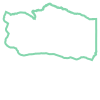

In [106]:
sb_county.boundary.iloc[0]

Declare splitting function

In [145]:
def split_equal_area(num_splits, polygon):
    circle = (
    shapely
    .minimum_bounding_circle(polygon)
    .buffer(abs(polygon.iloc[[0]].total_bounds[0]) + 
            abs(polygon.iloc[[0]].total_bounds[2]))
    )

    centerpoint = circle.centroid

    # segmentation
    bnd = circle.boundary.segmentize(500)

    #Extract the coordinates of all vertices of the segmentized boundary line
    boundary_coords = list(bnd[0].coords)



    # make triangular polygons from center

    original_area = polygon.area
    split_areas = original_area/num_splits

    polygon_slices = [] #Store the intersection result in a list
    for c1, c2 in zip(boundary_coords, boundary_coords[1:]):
        circle_segment = shapely.MultiPoint([c1, c2, centerpoint[0]])
        hull = circle_segment.convex_hull
        polygon_slices.append( hull.intersection(polygon) )



    # Calculate the area of each intersection
    polygon_slice_areas = [p.area for p in polygon_slices]

    # Calculate the cumulative area
    slice_areas_cum = [float(x) for x in np.cumsum(polygon_slice_areas)] 

    # Calculate the optimal cumulative area
    optimal_cumulative_areas = [float(x) for x in np.cumsum([split_areas]*(num_splits-1))] 



    #Find the optimal indices to divide the polygon slices
    best_indices_to_split = [0]
    for optimal_area in optimal_cumulative_areas:
        diffs = [abs(optimal_area-x) for x in slice_areas_cum]
        best_split_index = diffs.index(min(diffs))
        best_indices_to_split.append(best_split_index)
    best_indices_to_split.append(len(boundary_coords))



    # Union the polygon_slices[0:2011] into one part, polygon_slices[2011:3949] into one, ...
    geometry_parts = []
    for i1, i2 in zip(best_indices_to_split, best_indices_to_split[1:]):
        geometry_parts.append(shapely.ops.unary_union(polygon_slices[i1:i2]))
    split_geom = gpd.GeoSeries(geometry_parts)



    # Plot the result
    ax2 = (
        polygon
        .boundary
        .plot(
            figsize=(10, 10), 
            color="black", 
            zorder=2, 
            linewidth=10
            )
        )
    split_geom.plot(ax=ax2, cmap="Accent", zorder=1)
    for part in split_geom:
        part_area_prc = round(100*part.area/original_area, 2)
        x, y = part.centroid.xy
        x = x[0]
        y = y[0]
        #Annotate each slice with the relative area
        ax2.annotate(f"{part_area_prc} %", xy=(x, y), fontsize=15)



    return split_geom

simplify and split county polygon

/tmp/ipykernel_805269/1916135249.py:21: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  original_area = polygon.area


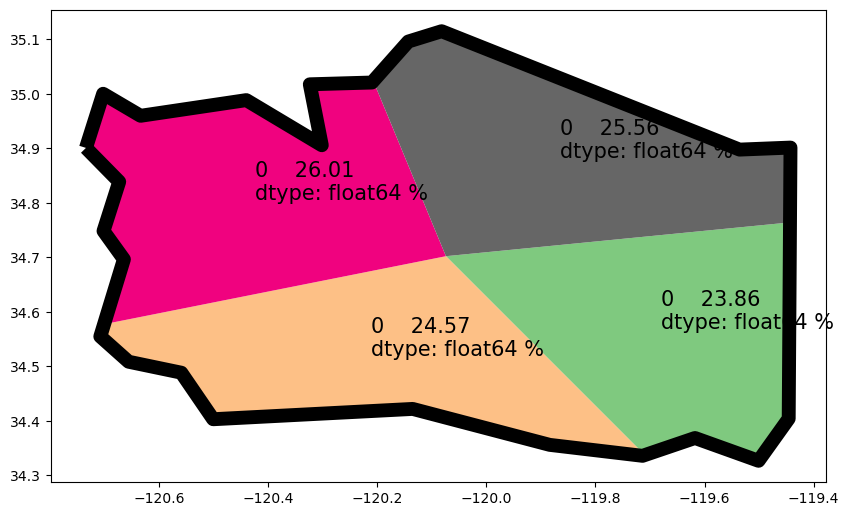

In [294]:
sb_simple = (
    sb_county
    #.to_crs("EPSG:3310")
    .simplify(0.02)
    .to_frame(name="geometry")
    .pipe(gpd.GeoDataFrame)
    )

first_split = split_equal_area(4, sb_simple)

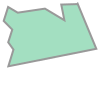

In [371]:
first_split[2]

get geojson

In [296]:
# sb_json = (
#         sb_county.simplify(0.02).to_frame(name="geometry")
#         .to_geo_dict() # convert polygon to geojson format
#         ["features"][0] # select first and only feature
#         ["geometry"] # select geometry attribute
#     )

# #sb_json["coordinates"] = [[*sb_json["coordinates"][0]]]

# len(sb_json["coordinates"][0])

In [299]:
# craft json making function
def declare_jsons(polygon):

    num_verts = 31
    simplify_val = 0.00001

    while num_verts > 30:
        sb_json = (
            gpd.GeoSeries(polygon).simplify(simplify_val).to_frame(name="geometry")
            .to_geo_dict() # convert polygon to geojson format
            ["features"][0] # select first and only feature
            ["geometry"] # select geometry attribute
        )

        num_verts = len(sb_json["coordinates"][0])
        simplify_val = simplify_val * 1.5


    print(f"Number of verticies: {num_verts}")

    return sb_json

In [300]:
# make jsons 0-3 for each polygon on the first split
json_list = [f"sb_json_{i}" for i in range(4)]

for i in range(len(json_list)):
    vars()[json_list[i]] = declare_jsons(first_split[i])

Number of verticies: 7
Number of verticies: 11
Number of verticies: 14
Number of verticies: 8


In [301]:
geometry_filter_0

{'type': 'GeometryFilter',
 'field_name': 'geometry',
 'config': {'type': 'Polygon',
  'coordinates': (((15614.573038041479, -406700.2139416705),
    (9975.642428974037, -406502.87301573483),
    (6939.340897150432, -404688.0689833976),
    (-8795.996759352925, -371922.6234286869),
    (51119.654785448605, -368150.03979859105),
    (51406.69285930394, -396992.81062671077),
    (51019.40858851746, -398363.6334123751),
    (50245.76999575751, -398430.82635207893),
    (50118.03703938601, -399243.0041094376),
    (50950.98761544291, -401166.4406723138),
    (48018.75241019076, -403913.8310983279),
    (48119.60915825559, -404629.4663255182),
    (45912.33609744707, -409776.0594737935),
    (40854.30405980177, -407793.09619993437),
    (38181.937423291434, -405958.627936522),
    (35174.70742857983, -405186.7399445963),
    (32058.815827470033, -405423.12149148947),
    (30706.993001730974, -406786.64517516503),
    (26341.51318490164, -408846.525404193),
    (18660.382322330563, -405614.8

In [302]:
gpd.GeoSeries(first_split[0]).to_frame(name = "geometry")

,geometry
0,"POLYGON ((-119.52634 34.33603, -119.61747 34.3..."


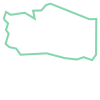

In [303]:
sb_county.simplify(0.02).to_frame(name="geometry").boundary.iloc[0]

Set filters

In [304]:
# set geometry filter
# geometry_filter = {
#     "type": "GeometryFilter", 
#     "field_name": "geometry", 
#     "config": sb_json
# }

# declare geometry filters 0-3
geom_filter_list = [f"geometry_filter_{i}" for i in range(4)]

for i in range(len(geom_filter_list)):
    vars()[geom_filter_list[i]] = {
        "type": "GeometryFilter", 
        "field_name": "geometry", 
        "config": vars()[f"sb_json_{i}"]
    }

# # set date filter
# date_range_filter = {
#     "type": "DateRangeFilter", 
#     "field_name": "acquired",  
#     "config": { 
#         "gte": "2018-01-01T00:00:00.000Z",
#         "lt":  "2024-01-01T00:00:00.000Z"
#     }
# }

# DEMO DATE RANGE FILTER
# ONLY FOR ONE MONTH
date_range_filter = {
    "type": "DateRangeFilter", 
    "field_name": "acquired",  
    "config": { 
        "gte": "2022-05-01T00:00:00.000Z",
        "lt":  "2022-06-01T00:00:00.000Z"
    }
}

# set cloud cover filter
cloud_cover_filter = {
    "type": "RangeFilter", 
    "field_name": "cloud_cover", 
    "config": {
        "lt": 0.5
    }
}

# # MAKING CLOUD FILTER STRICTER TO MAKE NUM SCENES UNDER 500
# cloud_cover_filter = {
#     "type": "RangeFilter", 
#     "field_name": "cloud_cover", 
#     "config": {
#         "lt": 0.01
#     }
# }

# combine filters
# combined_filters = {
#     "type": "AndFilter", 
#     "config": [geometry_filter, date_range_filter, cloud_cover_filter]
# }

combined_filter_list = [f"combined_filters_{i}" for i in range(4)]

for i in range(len(combined_filter_list)): 
    vars()[combined_filter_list[i]] = {
        "type": "AndFilter", 
        "config": [vars()[f"geometry_filter_{i}"], date_range_filter, cloud_cover_filter]
    }

In [305]:
combined_filters_0

{'type': 'AndFilter',
 'config': [{'type': 'GeometryFilter',
   'field_name': 'geometry',
   'config': {'type': 'Polygon',
    'coordinates': (((-119.50096541767341, 34.326926813516394),
      (-119.61747443965668, 34.368734811119914),
      (-119.70954192706371, 34.33743270308518),
      (-120.07423004137266, 34.702120817394125),
      (-119.44327205138791, 34.76408443335752),
      (-119.44565241492683, 34.404261824966895),
      (-119.50096541767341, 34.326926813516394)),)}},
  {'type': 'DateRangeFilter',
   'field_name': 'acquired',
   'config': {'gte': '2022-05-01T00:00:00.000Z',
    'lt': '2022-06-01T00:00:00.000Z'}},
  {'type': 'RangeFilter', 'field_name': 'cloud_cover', 'config': {'lt': 0.5}}]}

Run quick search based on filters

In [306]:
# item_types = ["PSScene"]

# search_request = {
#     "item_types": item_types,
#     "filter": combined_filters_0
# }

# search_result = \
#     requests.post(
#         "https://api.planet.com/data/v1/quick-search",
#         auth = HTTPBasicAuth(planet_key, ''), 
#         json = search_request
#     )

# print(search_result)

In [307]:
def quick_search(filters):
    item_types = ["PSScene"]

    search_request = {
        "item_types": item_types,
        "filter": filters
    }

    search_result = \
        requests.post(
            "https://api.planet.com/data/v1/quick-search",
            auth = HTTPBasicAuth(planet_key, ''), 
            json = search_request
        )

    print(search_result)

    return search_result

search_result_0 = quick_search(combined_filters_0)
search_result_1 = quick_search(combined_filters_1)
search_result_2 = quick_search(combined_filters_2)
search_result_3 = quick_search(combined_filters_3)

<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>


In [308]:
print(search_result_0.text)

{"_links": {"_first": "https://api.planet.com/data/v1/searches/8e4b87842ca74030824ed3eef780a6b7/results?_page=eyJwYWdlX3NpemUiOiAyNTAsICJzb3J0X2J5IjogInB1Ymxpc2hlZCIsICJzb3J0X2Rlc2MiOiB0cnVlLCAic29ydF9zdGFydCI6IG51bGwsICJzb3J0X2xhc3RfaWQiOiBudWxsLCAic29ydF9wcmV2IjogZmFsc2UsICJxdWVyeV9wYXJhbXMiOiB7fX0%3D", "_next": "https://api.planet.com/data/v1/searches/8e4b87842ca74030824ed3eef780a6b7/results?_page=eyJwYWdlX3NpemUiOiAyNTAsICJzb3J0X2J5IjogInB1Ymxpc2hlZCIsICJzb3J0X2Rlc2MiOiB0cnVlLCAic29ydF9zdGFydCI6ICIyMDIyLTA1LTAyVDIwOjQ0OjQ2LjAwMDAwMFoiLCAic29ydF9sYXN0X2lkIjogIjIwMjIwNTAxXzE3NDgxMV84OF8yNDVkIiwgInNvcnRfcHJldiI6IGZhbHNlLCAicXVlcnlfcGFyYW1zIjoge319", "_self": "https://api.planet.com/data/v1/searches/8e4b87842ca74030824ed3eef780a6b7/results?_page=eyJwYWdlX3NpemUiOiAyNTAsICJzb3J0X2J5IjogInB1Ymxpc2hlZCIsICJzb3J0X2Rlc2MiOiB0cnVlLCAic29ydF9zdGFydCI6IG51bGwsICJzb3J0X2xhc3RfaWQiOiBudWxsLCAic29ydF9wcmV2IjogZmFsc2UsICJxdWVyeV9wYXJhbXMiOiB7fX0%3D"}, "features": [{"_links": {"_self": "https://api

Print first 250 scene ids

In [ ]:
# first_ids = [feature['id'] for feature in search_result.json()["features"]]
# first_ids

['20220504_175310_25_2442',
 '20220504_175307_95_2442',
 '20220531_183405_05_240a',
 '20220528_181835_24_2484',
 '20220528_181832_96_2484',
 '20220527_182202_48_2486',
 '20220524_181010_18_2231',
 '20220524_181012_39_2231',
 '20220524_181016_82_2231',
 '20220524_181014_61_2231',
 '20220524_181007_97_2231',
 '20220520_181316_23_2231',
 '20220520_181311_81_2231',
 '20220520_181309_60_2231',
 '20220520_181307_39_2231',
 '20220515_182234_79_247c',
 '20220515_182232_50_247c',
 '20220510_182223_42_24a5',
 '20220510_174909_51_2453',
 '20220505_174909_18_220b',
 '20220505_174906_97_220b',
 '20220525_174739_28_2442',
 '20220525_174734_35_2442',
 '20220525_174736_81_2442',
 '20220525_174731_88_2442',
 '20220524_182148_73_2446',
 '20220524_182146_44_2446',
 '20220524_182144_16_2446',
 '20220524_182141_88_2446',
 '20220524_182139_60_2446',
 '20220529_175127_48_2451',
 '20220529_175125_21_2451',
 '20220529_175122_94_2451',
 '20220529_175120_66_2451',
 '20220501_174832_89_2455',
 '20220501_182002_84

Print all scene ids

In [ ]:
# all_ids = []
# all_ids.extend(first_ids)
# loop_trigger = len(first_ids)

# id_json = search_result.json()

# while loop_trigger == 250:
#     next_url = id_json["_links"]["_next"]

#     next_250 = session.get(next_url)

#     id_json = next_250.json()

#     features = next_250.json()["features"]


#     id_list = []

#     for f in features:
        
#         # print id for each feature
#         id_str = f["id"]
#         id_list.extend([id_str])

#     all_ids.extend(id_list)

#     print(f"num ids: {len(all_ids)}")

#     loop_trigger = len(id_list)

num ids: 500
num ids: 565


In [327]:
def get_ids(search_result):
    first_ids = [feature['id'] for feature in search_result.json()["features"]]
    

    all_ids = []
    all_ids.extend(first_ids)
    loop_trigger = len(first_ids)

    id_json = search_result.json()

    while loop_trigger == 250:
        next_url = id_json["_links"]["_next"]

        next_250 = session.get(next_url)

        id_json = next_250.json()

        features = next_250.json()["features"]


        id_list = []

        for f in features:
            
            # print id for each feature
            id_str = f["id"]
            id_list.extend([id_str])

        all_ids.extend(id_list)

        print(f"num ids: {len(all_ids)}")

        loop_trigger = len(id_list)
    
    return all_ids

ids_0 = get_ids(search_result_0)
ids_1 = get_ids(search_result_1)
ids_2 = get_ids(search_result_2)
ids_3 = get_ids(search_result_3)

all_ids = []
for ids in [ids_0, ids_1, ids_2, ids_3]:
    all_ids.extend(ids)

num ids: 262
num ids: 275


In [328]:
print(len(all_ids))

981


In [59]:
# not_str_cnt = 0
# for id in all_ids:
#     if isinstance(id, str) != True:
#         print(f"{id} not string!!")
#         not_str_cnt = not_str_cnt + 1

# print(f"not string count: {not_str_cnt}")

### Requests example

In this notebook, we will be using `requests` to communicate with the orders v2 API. First, we will check our orders list to make sure authentication and communication is working as expected.

We want to get a response code of `200` from this API call. To troubleshoot other response codes, see the [List Orders](https://developers.planet.com/apis/orders/reference/#tag/Orders/operation/listOrders) API reference.

In [330]:
auth = HTTPBasicAuth(planet_key, "")
order_response = requests.get(orders_api_url, auth=auth)
print(order_response)

<Response [200]>


Print previous orders

In [331]:
orders = order_response.json()['orders']
[r['name'] for r in orders[:5]]

['wildfire_prep_dataset_test2',
 'wildfire_prep_dataset_test',
 'wildfire_imagery',
 'wildfire may 2023',
 'wildfire july 2023']

Make order request

In [ ]:
# # set content type to json
# headers = {"content-type": "application/json"}

# # init order parameters
# product = [
#     { 
#         "item_ids": all_ids, 
#         "item_type": "PSScene", 
#         "product_bundle": "analytic_8b_sr_udm2", 
#     }
# ]

# order_request = {
#     "name": "wildfire_imagery", 
#     "products": product, 
#     "delivery": {"single_archive": True, "archive_type": "zip"}
# }

In [372]:
# set content type to json
headers = {"content-type": "application/json"}

def order_setup(ids, name_extention):

    # init order parameters
    product = [
        { 
            "item_ids": ids, 
            "item_type": "PSScene", 
            "product_bundle": "analytic_8b_sr_udm2", 
        }
    ]

    order_request = {
        "name": f"wildfire_imagery_{name_extention}", 
        "products": product, 
        "delivery": {"single_archive": True, "archive_type": "zip"}
    }

    return order_request, product

order_request_0, product_0 = order_setup(ids_0, "right")
order_request_1, product_1 = order_setup(ids_1, "bottom")
order_request_2, product_2 = order_setup(ids_2, "left")
order_request_3, product_3 = order_setup(ids_3, "top")

In [373]:
def place_order(request, auth):

    # make order request
    response = requests.post(
        orders_api_url, 
        data = json.dumps(request), 
        auth = auth, 
        headers = headers
        )
    print(response.json())

    # get ids of scenes
    order_id = response.json()["id"]
    print(order_id)

    # construct the url of our order
    order_url = orders_api_url + '/' + order_id
    
    return order_url

### Clip to Santa Barbara County

In [374]:
# # init clip parameters
# clip =  {
#     "clip": {
#         "aoi": sb_json
#     }
# }

# clip_request = { 
#     "name": "wildfire santa barbara", 
#     "products": product, 
#     "tools": [clip], 
#     "delivery": {"single_archive": True, "archive_type": "zip"}
# }

In [377]:
def init_clip(json, product):
    # init clip parameters
    clip =  {
        "clip": {
            "aoi": json
        }
    }

    # clip = {
    #     "type": "clip",
    #     "config": {
    #         "aoi": json
    #     }
    # }



    clip_request = { 
        "name": "wildfire santa barbara", 
        "products": product, 
        "tools": [clip], 
        "delivery": {"single_archive": True, "archive_type": "zip"}
    }

    return clip_request

clip_request_0 = init_clip(sb_json_0, product_0)
clip_request_1 = init_clip(sb_json_1, product_1)
clip_request_2 = init_clip(sb_json_2, product_2)
clip_request_3 = init_clip(sb_json_3, product_3)

##### Place order and check for order success

In [378]:
# we don't have permission to run the clip tool
clip_order_url_0 = place_order(clip_request_0, auth)
clip_order_url_1 = place_order(clip_request_1, auth)
clip_order_url_2 = place_order(clip_request_2, auth)
clip_order_url_3 = place_order(clip_request_3, auth)

{'field': None, 'general': [{'message': "Unable to accept order: Your organization does not have permission to run the 'clip' tool"}]}


KeyError: 'id'

In [65]:
# requests.post(
#         orders_api_url, 
#         data = json.dumps(clip_request), 
#         auth = auth, 
#         headers = headers
#         ).json()

In [66]:
#print(json.dumps(clip_request, indent = 4))

In [379]:
# clip tool still doesn't work, so I'll just order normally for now
# order_url = place_order(order_request, auth)

order_url_0 = place_order(order_request_0, auth)
order_url_1 = place_order(order_request_1, auth)
order_url_2 = place_order(order_request_2, auth)
order_url_3 = place_order(order_request_3, auth)

{'_links': {'_self': 'https://api.planet.com/compute/ops/orders/v2/6210c7df-cca7-4f37-a7fb-872144454698'}, 'created_on': '2025-04-08T10:17:13.87387Z', 'delivery': {'archive_filename': 'output.zip', 'archive_type': 'zip', 'single_archive': True}, 'error_hints': [], 'id': '6210c7df-cca7-4f37-a7fb-872144454698', 'last_message': 'Preparing order', 'last_modified': '2025-04-08T10:17:13.87387Z', 'name': 'wildfire_imagery_right', 'products': [{'item_ids': ['20220528_181835_24_2484', '20220528_181832_96_2484', '20220524_181016_82_2231', '20220524_181014_61_2231', '20220520_181316_23_2231', '20220505_174909_18_220b', '20220524_182146_44_2446', '20220501_182002_84_249a', '20220501_182000_56_249a', '20220501_181958_29_249a', '20220501_181956_01_249a', '20220501_181953_74_249a', '20220502_174952_86_245c', '20220502_174950_58_245c', '20220503_183314_17_227a', '20220503_183311_89_227a', '20220503_183309_61_227a', '20220503_183307_32_227a', '20220531_183407_26_240a', '20220531_174839_43_2448', '20220

### Poll for order success

In [365]:
def poll_for_success(order_url, auth, num_loops = 30): 
    i = 0
    while(i < num_loops): 

        # iterate
        i += 1

        # get order request
        r = requests.get(order_url, auth = auth)
        response = r.json()

        # grab current state
        state = response["orders"][0]["state"]
        print(state)

        # compare it to a variety of end states and print it
        end_states = ["success", "failed", "partial"]
        if state in end_states:
            print(f"End State: {state}")
            break

        # wait 30 secs
        time.sleep(30)

# poll_for_success(orders_api_url, auth)

In [69]:
# test = requests.get(orders_api_url, auth = auth).json()
# test["orders"][0]["state"]

In [ ]:
# we don't have permission to run the clip tool
poll_for_success(clip_order_url, auth)

View results of order

In [225]:
r = requests.get(orders_api_url, auth = auth)
clip_response = r.json()
order_results = clip_response["orders"][0]["state"]
order_results

'running'

### download

In [ ]:
# download results locally and individually
def download_results(results, overwrite=False):
    results_urls = [r['location'] for r in results]
    results_names = [r['name'] for r in results]
    print('{} items to download'.format(len(results_urls)))
    
    for url, name in zip(results_urls, results_names):
        path = pathlib.Path(os.path.join('..', '..', '..', 'data', name))
        
        if overwrite or not path.exists():
            print('downloading {} to {}'.format(name, path))
            r = requests.get(url, allow_redirects=True)
            path.parent.mkdir(parents=True, exist_ok=True)
            open(path, 'wb').write(r.content)
        else:
            print('{} already exists, skipping {}'.format(path, name))

In [ ]:
download_results(order_results)